In [1]:
import ee
import geemap
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
import datetime

print("Imports loaded.")

Imports loaded.


In [2]:
ee.Authenticate()

True

In [3]:
ee.Initialize(project="unique-spirit-494108-g2")
print("Earth Engine initialized OK.")

Earth Engine initialized OK.


Question (4 pts): Throughout this lab, we will be comparing SAR GRD level data to compare the same AOI over different periods of time. Why is it important to keep the orbit direction consistent when comparing scenes over time?

ANSWER: SAR images change depending on whether the satellite is in ascending or descending pass, which affects viewing geometry. If orbit direction differs between scenes, apparent changes may come from imaging geometry rather than real changes on the ground.

In [4]:
# Area of interest: Kraków and surrounding urban/peri-urban area
aoi = ee.Geometry.Rectangle([19.85, 49.95, 20.20, 50.14])

# Analysis settings
ORBIT_PASS = "ASCENDING"
MODE = "IW"
RESOLUTION = 10

# Year range used later in the notebook
years = list(range(2015, 2025))

m = geemap.Map()
m.centerObject(aoi, 10)
m.addLayer(aoi, {"color": "red"}, "AOI")
display(m)

Map(center=[50.04506888629718, 20.024999999999867], controls=(WidgetControl(options=['position', 'transparent_…

In [5]:
def get_s1_collection(start_date, end_date, region=aoi,
                      orbit_pass=ORBIT_PASS,
                      mode=MODE,
                      resolution=RESOLUTION):
    """
    Return a filtered Sentinel-1 GRD ImageCollection.
    """
    collection = (
        ee.ImageCollection("COPERNICUS/S1_GRD")                     # loads all Sentinel images
        .filterBounds(region)                                       # only from Kraków
        #YOUR CODE HERE (10 pts)
        .filterDate(start_date, end_date)                           # specific time range
        .filter(ee.Filter.eq('instrumentMode', mode))               # specific radar mode
        .filter(ee.Filter.eq('orbitProperties_pass', orbit_pass))   # satelite direction
        .filter(ee.Filter.eq('resolution_meters', resolution))      # specific resolution
    )

    return collection


def get_monthly_median(year, month=8, region=aoi):
    """
    Return the median Sentinel-1 image for a given month and year.
    By default, this is August because it reduces seasonal variation
    and avoids snow-related complications.
    """
    start = f"{year}-{month:02d}-01"                        # first day of the month
    if month == 12:                     
        end = f"{year + 1}-01-01"                           # for december goes to january 01 next year
    else:
        end = f"{year}-{month + 1:02d}-01"                  # for other monts goes for first of the next month

    #YOUR CODE HERE (10 pts). IN SECTION 4, YOU MANUALLY GOT THE COLLECTION AND SET THE MEDIAN.
    #SINCE WE INTEND TO DO THIS MULTIPLE TIMES, LETS PUT THIS IN A FUNCTION

    collection = get_s1_collection(start, end, region)      # filtered Sentiel collection

    image = collection.median()                             # median image
    
    return image.set({                                      # ads month, year and count of images from Sentiel to the photo
        "year": year,
        "month": month,
        "scene_count": collection.size()
    })


def show_scene_metadata(collection):
    """
    Print selected metadata for scenes in a collection.
    Useful for discussing repeat intervals and duplicate dates.
    """
    #YOUR CODE HERE (10 pts). Fill in this function with additional metadata required to answer any questions you may have
    times = collection.aggregate_array("system:time_start").getInfo()                               # pulls a timestamps in milliseconds
    passes = collection.aggregate_array("orbitProperties_pass").getInfo()                           # ascending or descending
    platforms = collection.aggregate_array("platform_number").getInfo()                             # Sentinel-1A or 1B
    orbit_ralative = collection.aggregate_array("relativeOrbitNumber_start").getInfo()              # 
    slice_number = collection.aggregate_array("sliceNumber").getInfo()
    total_sloices = collection.aggregate_array("totalSlices").getInfo()
    models = collection.aggregate_array("instrumentMode").getInfo()
    polarization = collection.aggregate_array("transmitterReceiverPolarisation").getInfo()          # polarization for every image (VV or VH)
    resolution = collection.aggregate_array("resolution_meters").getInfo()
    angles = collection.aggregate_array("meanIncidenceAngle").getInfo()                             # look angle for backscatter values
    orbit_number = collection.aggregate_array("orbitNumber_start").getInfo()                        # exact satellite orbit number 

    # combines elements from each list
    for t, p, sat, pol, ang, orb_n in zip(times, passes, platforms, orbit_ralative, slice_number, total_sloices, models, polarization, resolution, angles, orbit_number):
        dt = datetime.datetime.utcfromtimestamp(t / 1000)                                           # converts to seconds then to normal date
        print(f"{dt.date()} | {p} | S1{sat} | Orbit {orb_n} | Angle {ang:.2f} | {pol} ")              # 2026-04-22 | ASCENDING | S1A | Orbit 45 | Angle 34.55 | VH


def fixed_histogram(image, region, band, hist_min, hist_max, n_bins=100, scale=10):
    """
    Compute a fixed histogram for one band of an Earth Engine image.
    Returns bin centers, counts, and bin width.
    """
    hist = image.select(band).reduceRegion(
        reducer=ee.Reducer.fixedHistogram(hist_min, hist_max, n_bins),
        geometry=region,
        scale=scale,
        maxPixels=1e9,
        bestEffort=True
    ).get(band)

    hist = ee.List(hist).getInfo()
    bin_edges = [row[0] for row in hist]
    counts = [row[1] for row in hist]
    bin_width = (hist_max - hist_min) / n_bins
    bin_centers = [edge + bin_width / 2 for edge in bin_edges]

    return bin_centers, counts, bin_width


def normalize_counts(counts):
    total = sum(counts)
    if total == 0:
        return counts
    return [c / total for c in counts]


def region_stats(image, region, band):
    """
    Return mean, median, std dev, and max for a selected band.
    """
    stats = image.select(band).reduceRegion(
        reducer=(
            ee.Reducer.mean()
            .combine(ee.Reducer.median(), sharedInputs=True)
            .combine(ee.Reducer.stdDev(), sharedInputs=True)
            .combine(ee.Reducer.max(), sharedInputs=True)
        ),
        geometry=region,
        scale=10,
        maxPixels=1e9,
        bestEffort=True
    ).getInfo()

    return {
        "mean": stats.get(f"{band}_mean"),
        "median": stats.get(f"{band}_median"),
        "stdDev": stats.get(f"{band}_stdDev"),
        "max": stats.get(f"{band}_max"),
    }

print("Helper functions defined.")

Helper functions defined.


In [6]:
# Visualization presets
vv_vis = {"min": -20, "max": 0}
vh_vis = {"min": -28, "max": -5}
#YOU WILL NEED TO WRITE THE get_s1_collection FUNCTION TO GET THIS TO WORK. ONCE YOU HAVE
#THE FUNCTION WORKING, PLACE IT IN THE FUNCTIONS CODE BLOCK IN SECTION 3.
jan_2024 = get_s1_collection("2024-01-01", "2024-02-01", region=aoi)

#YOU WILL NEED TO ADAPT THE show_scene_metadata() FUNCTION TO ANSWER THE QUESTION BELOW
print("Image count:", jan_2024.size().getInfo())
show_scene_metadata(jan_2024)

jan_2024_img = jan_2024.median().clip(aoi)

m = geemap.Map()
m.centerObject(aoi, 10)

#If we were plotting just one img, you would simply use the line below. A split_map allows
#two scenes to be compared via a slider bar.
#m.addLayer(jan_2024_img.select("VV"), vv_vis, "VV January 2024")

m.split_map(
    left_layer=geemap.ee_tile_layer(jan_2024_img.select("VV"), vv_vis, "VV January 2024"),
    right_layer=geemap.ee_tile_layer(jan_2024_img.select("VH"), vh_vis, "VH January 2024")
)
display(m)

Image count: 10


Map(center=[50.04506888629718, 20.024999999999867], controls=(ZoomControl(options=['position', 'zoom_in_text',…

QUESTION (4 pts): We know Sentinel-1 has an approximately 6-day repeat time. However, from the metadata presented above, there are 10 images that GEE grabbed, two for each acquisition day. Why is that? Do not guess, look into the metadata for those scenes to get your answer. You will need to modify the metadata function in the helper functions code block above. Please also adjust the print function to print the metadata field you thinks supports your answer

Some common metadata fields are: time_start, platform_number, orbitProperties_pass, relativeOrbitNumber_start, sliceNumber, totalSlices, instrumentMode, transmitterReceiverPolarisation, resolution_meters, and orbitNumber_start.

ANSWER: Sentinel-1 typically captures the same area twice per day on different orbital passes—once in an ascending pass and once in a descending pass. This is directly visible in the metadata field orbitProperties_pass, which shows two distinct values (ASCENDING and DESCENDING) for the same date, confirming the duplication is due to orbit direction rather than additional revisit days.

In [7]:
# Build one August median image for every year
images_by_year = {year: get_monthly_median(year, month=8, region=aoi) for year in years}

first_year = years[0]
last_year = years[-1]

img_first = images_by_year[first_year]
img_last = images_by_year[last_year]

m = geemap.Map()
m.centerObject(aoi, 11)
m.split_map(
    left_layer=geemap.ee_tile_layer(img_first.select("VV"), vv_vis, f"VV {first_year}"),
    right_layer=geemap.ee_tile_layer(img_last.select("VV"), vv_vis, f"VV {last_year}")
)
display(m)

Map(center=[50.04506888629718, 20.024999999999867], controls=(ZoomControl(options=['position', 'zoom_in_text',…

QUESTION (8 pts): Compare the 2015 and 2025 median maps carefully.

Start with the old town. Do you notice much change? Why do you think that is?
Find an area that has significant change in bright pixels. What does this represent?
What about the darkest pixels?
Pixels or groups of pixels that are consistently bright across many years are excellent candidates for the persistent scatterer, which we will cover in a later lab. What features do you think might make excellent candidates for persistent scatterer analysis?

ANSWER: The Old Town shows little change because its dense historic buildings and infrastructure have remained largely unchanged. Areas with a strong increase in bright pixels likely represent new urban development or infrastructure, while consistently dark pixels are often water bodies or open land; long-lasting bright pixels on buildings, bridges, towers, and other permanent structures are excellent candidates for persistent scatterer analysis.

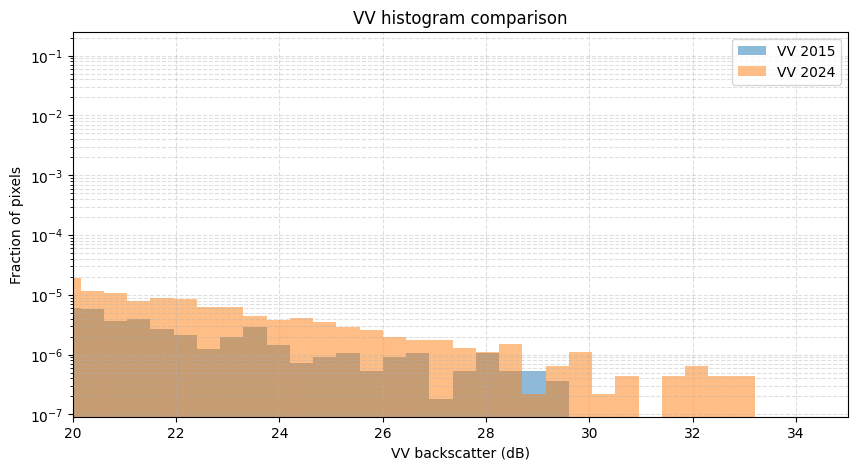

2015 VV stats: {'mean': -8.672231229609427, 'median': -8.875194515916217, 'stdDev': 3.06930373459068, 'max': 29.39563219751134}
2024 VV stats: {'mean': -9.286140736658622, 'median': -9.750873222813965, 'stdDev': 3.426506464939447, 'max': 33.13410592782661}


In [8]:
# Histogram settings
vv_hist_min = -10
vv_hist_max = 35
vv_hist_bins = 100

x1, y1, bw1 = fixed_histogram(img_first, aoi, band="VV",
                              hist_min=vv_hist_min, hist_max=vv_hist_max,
                              n_bins=vv_hist_bins)
x2, y2, bw2 = fixed_histogram(img_last, aoi, band="VV",
                              hist_min=vv_hist_min, hist_max=vv_hist_max,
                              n_bins=vv_hist_bins)

y1n = normalize_counts(y1)
y2n = normalize_counts(y2)

plt.figure(figsize=(10, 5))
plt.bar(x1, y1n, width=bw1, alpha=0.5, label=f"VV {first_year}")
plt.bar(x2, y2n, width=bw2, alpha=0.5, label=f"VV {last_year}")
plt.xlim(20, 35)
plt.xlabel("VV backscatter (dB)")
plt.ylabel("Fraction of pixels")
plt.title("VV histogram comparison")
plt.yscale("log")
plt.grid(True, which="both", linestyle="--", alpha=0.4)
plt.legend()
plt.show()

stats_first = region_stats(img_first, aoi, "VV")
stats_last = region_stats(img_last, aoi, "VV")

print(f"{first_year} VV stats:", stats_first)
print(f"{last_year} VV stats:", stats_last)

QUESTION (4 pts): What do you notice about the distribution on the bright side tail of the distribution of pixel brightness? Discuss both the number of bright pixels and their distribution, and what each represents. ADJUST THE X-AXIS IN THE CODE TO GRAB THE PART OF THE HISTOGRAM THAT SUPPORTS YOUR ANSWER BELOW

ANSWER: The bright-side tail extends farther in 2024 than in 2015. This indicates the presence of more extremely reflective targets, associated with dense urban structures, large buildings, bridges, or other man-made infrastructure. The number of bright pixels remains relatively small compared to the overall image, but their distribution is broader in 2024, suggesting a greater variety and extent of highly reflective surfaces. A longer and wider bright tail generally reflects increased urbanization and more strong radar scatterers across the study area.

In [9]:
ratio_first = img_first.select("VV").subtract(
    img_first.select("VH")
).rename("VVVH")

ratio_last = img_last.select("VV").subtract(
    img_last.select("VH")
).rename("VVVH")

ratio_change = ratio_last.subtract(ratio_first).rename("dVVVH")

Map = geemap.Map(center=[50.06, 19.94], zoom=11)

Map.addLayer(
    ratio_first,
    {"min": 0, "max": 15, "palette": ["blue", "white", "red"]},
    f"VV-VH {first_year}"
)

Map.addLayer(
    ratio_last,
    {"min": 0, "max": 15, "palette": ["blue", "white", "red"]},
    f"VV-VH {last_year}"
)

Map

Map(center=[50.06, 19.94], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright'…

QUESTION (4 pts): Where do you notice the biggest changes in the VV-VH ratio. Focus not only on the largest increases, but also the largest decreases. In doing so, are we making a qualitative or quantitative assesment?

ANSWER: The largest increases in the VV−VH ratio appear in the red areas, which correspond to dense urban features. The largest decreases occur in the blue areas, which are associated with vegetation or other land-cover types that increase volumetric scattering and therefore strengthen the VH signal.

In [10]:
# Visualization presets
change_vis = {"min": -3, "max": 3, "palette": ["blue", "white", "red"]}

ratio_change = ratio_last.subtract(ratio_first).rename("dVVVH")

m2 = geemap.Map()
m2.centerObject(aoi, 11)
m2.addLayer(ratio_change, change_vis, "Change in VV-VH")
display(m2)

Map(center=[50.04506888629718, 20.024999999999867], controls=(WidgetControl(options=['position', 'transparent_…

QUESTION (4 pts): Investigate this change map carefully.

First, identify an area that had a large scale increase in this ratio. Why did VV increase relative to VH in this area?
Second, I want you to find the area in the top right of the map that had a significant decrease in VV/VH. You can use the code block below to highlight where it is. Using optical data (google maps is fine here), tell me what that feature is. Why do you think it may have had strong VV in 2015, and strong VH in 2025, even though they were both taken in August?
aoi_blue = ee.Geometry.Rectangle([19.85, 49.95, 20.20, 50.14])
m2.addLayer(aoi, {"color": "red"}, "AOI")

ANSWER: A large-scale increase in the VV−VH ratio is visible in areas of urban expansion and infrastructure development around the city. In these locations, VV increased relative to VH because new buildings, roads, and other hard surfaces produce strong surface scattering, resulting in higher VV backscatter compared to the volumetric scattering represented by VH.

In [11]:
low_thresh = 5
high_thresh = 9
change_thresh = 3

#WRITE THE LOGIC TO FLAG PIXELS THAT HAVE SATISFIED THE ABOVE THRESHOLDS. USEFUL LOGIC
#FUNCTIONS INCLUDE .And(), .Or(), .lt() for less than, .gt() for greater than
transition = (
    #YOUR CODE HERE (10 pts)
    ratio_first.lt(low_thresh)
    .And(ratio_last.gt(high_thresh))
    .And(ratio_change.gt(change_thresh))
).rename("transition")


#This block will print your fraction of the AOI that you have flagged
frac = transition.reduceRegion(
    reducer=ee.Reducer.mean(),
    geometry=aoi,
    scale=10,
    maxPixels=1e9
).get("transition").getInfo()

print("Fraction flagged:", frac)

m3 = geemap.Map()
m3.centerObject(aoi, 11)
m3.addLayer(img_last.select("VV"), vv_vis, f"VV {last_year}")
m3.addLayer(ratio_change, change_vis, "d(VV-VH)")
m3.addLayer(
    transition.updateMask(transition),
    {"min": 0, "max": 1, "palette": ["yellow"]},
    "Transition mask"
)
display(m3)

Fraction flagged: 0.009485053608796546


Map(center=[50.04506888629718, 20.024999999999867], controls=(WidgetControl(options=['position', 'transparent_…

QUESTION (4 pts): Why did you choose the thresholds that you chose? Was it easy, or even possible, to arrive at a classification scheme that you think accurately captured urban development in the Krakow area?

ANSWER: It was not easy to arrive at a classification scheme that accurately captured urban development in Kraków. The results are highly sensitive to the chosen thresholds, and many factors besides urban growth—such as vegetation changes, soil moisture, agricultural activity, and SAR speckle—can influence the VV−VH ratio. As a result, the classification identifies candidate areas of change, but it does not perfectly distinguish urban development from other land-cover changes without additional data and validation.

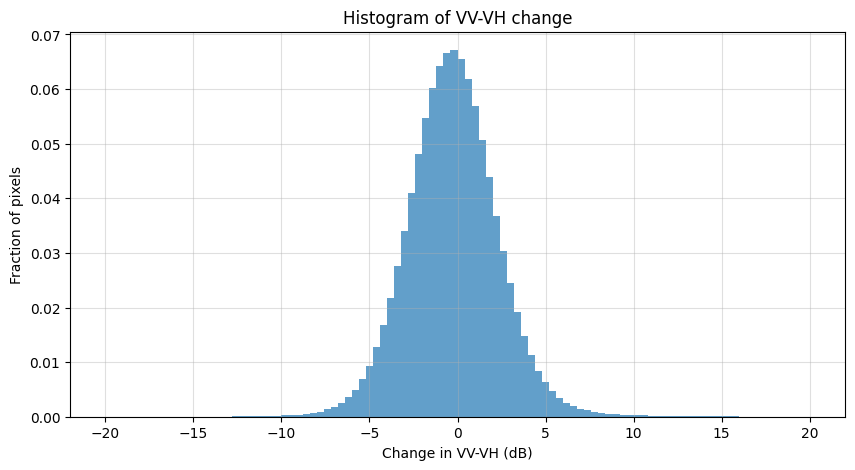

In [12]:
x_change, y_change, bw_change = fixed_histogram(
    ratio_change, aoi, "dVVVH", hist_min=-20, hist_max=20, n_bins=100
)

y_change_norm = normalize_counts(y_change)

plt.figure(figsize=(10, 5))
plt.bar(x_change, y_change_norm, width=bw_change, alpha=0.7)
plt.xlabel("Change in VV-VH (dB)")
plt.ylabel("Fraction of pixels")
plt.title("Histogram of VV-VH change")
plt.grid(True, alpha=0.4)
plt.show()

QUESTION (4 pts): First, notice that this histogram is not centered on 0, it is shifted slightly towards negative values. This means that VV is stronger in 2015 than in 2025! Does this go against all the analysis you just did? If this is confusing, go back to the very first split_image, comparing VV in 2015 and 2025. When we first did that, we were focused on the brightest pixels only. Now I want you to focus on the map as a whole, ignoring the brightest pixels. What can you say about the strength of VV returns in 2015 vs 2025. Thinking about what we have learned about scattering physics, what do you think might be the cause of this?

ANSWER: No, this does not contradict the earlier analysis. Previously, we focused on the brightest pixels, which are often associated with buildings, infrastructure, and other strong scatterers that may have increased over time. However, when considering the entire map, the histogram shows that the average VV backscatter is slightly lower in 2025 than in 2015. This suggests that although some urban areas became brighter, much of the landscape experienced weaker VV returns.

,year,frac_flagged
0,2015,0.658098
1,2016,0.489794
2,2017,0.489003
3,2018,0.590687
4,2019,0.625314
5,2020,0.640774
6,2021,0.611817
7,2022,0.623442
8,2023,0.604903
9,2024,0.590333


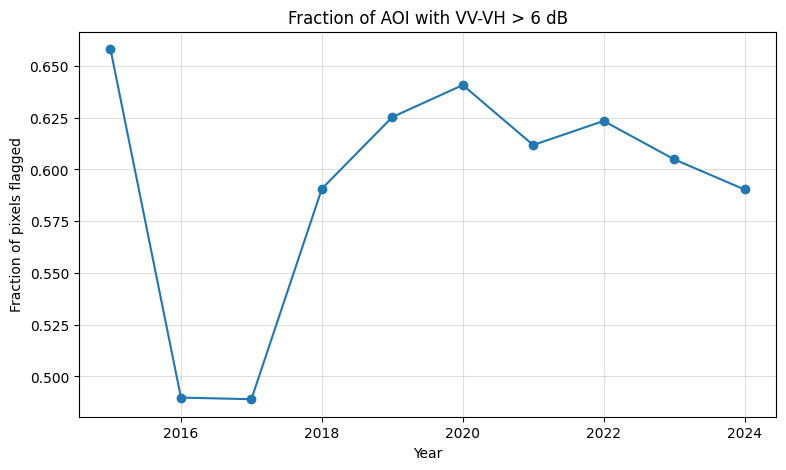

In [14]:
ratio_thresh = 6
rows = []

for year in years:
    yearly = images_by_year[year]
    ratio = yearly.select("VV").subtract(yearly.select("VH")).rename("VVVH")

    frac_flagged = ratio.gt(ratio_thresh).reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=aoi,
        scale=10,
        maxPixels=1e9
    ).get("VVVH").getInfo()

    rows.append({
        "year": year,
        "frac_flagged": frac_flagged
    })

df = pd.DataFrame(rows)
display(df)

plt.figure(figsize=(9, 5))
plt.plot(df["year"], df["frac_flagged"], marker="o")
plt.xlabel("Year")
plt.ylabel("Fraction of pixels flagged")
plt.title(f"Fraction of AOI with VV-VH > {ratio_thresh} dB")
plt.grid(True, alpha=0.4)
plt.show()

QUESTION (8 pts):
Why did you choose the threshold that you did?
This is our first attempt to actually quantify and track a specific metric of urban development over a longer time period. Do you think the metric you arrived at accurately quantifies the amount of urban development? Or do you think the metric shows overall trends in urban development, but that there may be too many assumptions to accurately quantify this?
What do you think may be happening with the outliers?

ANSWER: The 6 dB threshold captures overall urban trends, but environmental and geometric assumptions make it too volatile to accurately quantify exact surface area. The massive 2015 drop and post-2020 fluctuations are data artifacts caused by early satellite calibration issues and environmental noise like soil moisture or vegetation growth overriding the building signals.